# Pengembangan Early Warning System (EWS) Kualitas Air
**Proyek Matakuliah MLOps, Web Service, dan Data Mining**

## 2. Exploratory Data Analysis - EDA (5%)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load Dataset
path = r"D:\\ARFI\\Kuliah\\Semester 4\\PBL\\Data\\Refined_Aquaculture_Water_Suitability_Signals.csv"
dataset = pd.read_csv(path)
print(f'Shape: {dataset.shape}')
display(dataset.head())


Shape: (4300, 17)


,Temperature,Turbidity (cm),Dissolved Oxygen (mg/L),Biochemical Oxygen Demand (mg/L),Carbon Dioxide (CO2),pH,Total Alkalinity (mg L-1),Total Hardness (mg L-1),Calcium (mg L-1),Ammonia (mg L-1),Nitrite (mg L-1),Phosphorus (mg L-1),Hydrogen Sulfide (mg L-1),Plankton Count (No. L-1),Water Quality Label,Aquaculture Suitability Tier,Aquaculture Suitability Description
0,67.45,10.13,0.208,7.474,10.181,4.752,218.365,300.125,337.178,0.286,4.355,0.006,0.067,6070.0,2,Reduced Suitability,Reduced Suitability: Water conditions are unde...
1,64.63,94.02,11.434,10.860,14.861,3.085,273.940,8.427,363.661,0.096,2.183,0.005,0.023,251.0,2,Reduced Suitability,Reduced Suitability: Water conditions are unde...
2,65.12,90.65,12.431,12.810,12.320,9.649,220.813,11.726,309.371,0.975,4.902,0.007,0.065,7219.0,2,Reduced Suitability,Reduced Suitability: Water conditions are unde...
3,1.64,0.07,10.964,8.508,12.955,4.820,266.572,6.628,8.180,0.885,3.572,3.174,0.026,1230.0,2,Reduced Suitability,Reduced Suitability: Water conditions are unde...
4,64.86,2.12,1.362,13.335,13.603,10.244,252.108,339.892,253.997,0.802,4.656,3.855,0.061,1035.0,2,Reduced Suitability,Reduced Suitability: Water conditions are unde...


In [2]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4300 entries, 0 to 4299
Data columns (total 17 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Temperature                          4300 non-null   float64
 1   Turbidity (cm)                       4300 non-null   float64
 2   Dissolved Oxygen (mg/L)              4300 non-null   float64
 3   Biochemical Oxygen Demand (mg/L)     4300 non-null   float64
 4   Carbon Dioxide (CO2)                 4300 non-null   float64
 5   pH                                   4300 non-null   float64
 6   Total Alkalinity (mg L-1)            4300 non-null   float64
 7   Total Hardness (mg L-1)              4300 non-null   float64
 8   Calcium (mg L-1)                     4300 non-null   float64
 9   Ammonia (mg L-1)                     4300 non-null   float64
 10  Nitrite (mg L-1)                     4300 non-null   float64
 11  Phosphorus (mg L-1)           

In [3]:
print(f"Jumlah Missing value:\n{dataset.isna().sum()}")

Jumlah Missing value:
Temperature                            0
Turbidity (cm)                         0
Dissolved Oxygen (mg/L)                0
Biochemical Oxygen Demand (mg/L)       0
Carbon Dioxide (CO2)                   0
pH                                     0
Total Alkalinity (mg L-1)              0
Total Hardness (mg L-1)                0
Calcium (mg L-1)                       0
Ammonia (mg L-1)                       0
Nitrite (mg L-1)                       0
Phosphorus (mg L-1)                    0
Hydrogen Sulfide (mg L-1)              0
Plankton Count (No. L-1)               0
Water Quality Label                    0
Aquaculture Suitability Tier           0
Aquaculture Suitability Description    0
dtype: int64


In [4]:
print(f"Jumlah Duplikat{dataset.duplicated().sum()}")

Jumlah Duplikat0


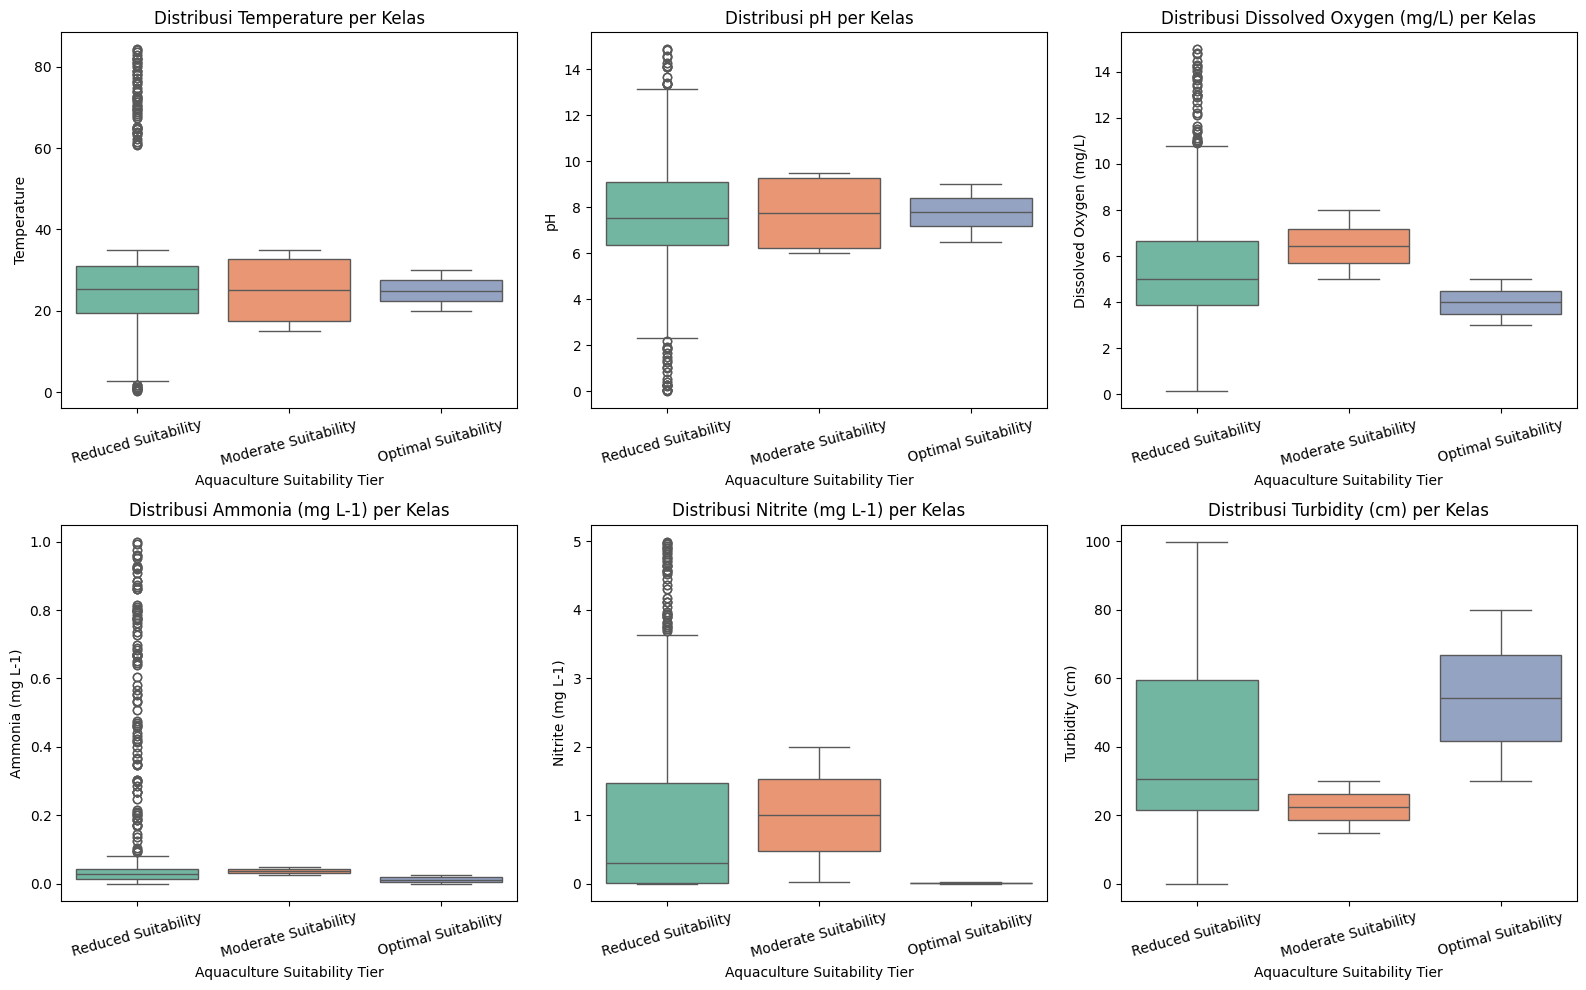

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Mendefinisikan 6 kolom penting yang akan divisualisasikan
kolom_penting = [
    'Temperature', 
    'pH', 
    'Dissolved Oxygen (mg/L)', 
    'Ammonia (mg L-1)', 
    'Nitrite (mg L-1)', 
    'Turbidity (cm)'
]

# 1. Boxplot untuk melihat isolasi mutlak per-fitur
plt.figure(figsize=(16, 10))
for i, col in enumerate(kolom_penting, 1):
    plt.subplot(2, 3, i)
    # Menggunakan boxplot untuk menekankan perbedaan dan distribusi antar kelas
    sns.boxplot(x='Aquaculture Suitability Tier', y=col, data=dataset, palette='Set2')
    plt.title(f'Distribusi {col} per Kelas')
    plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


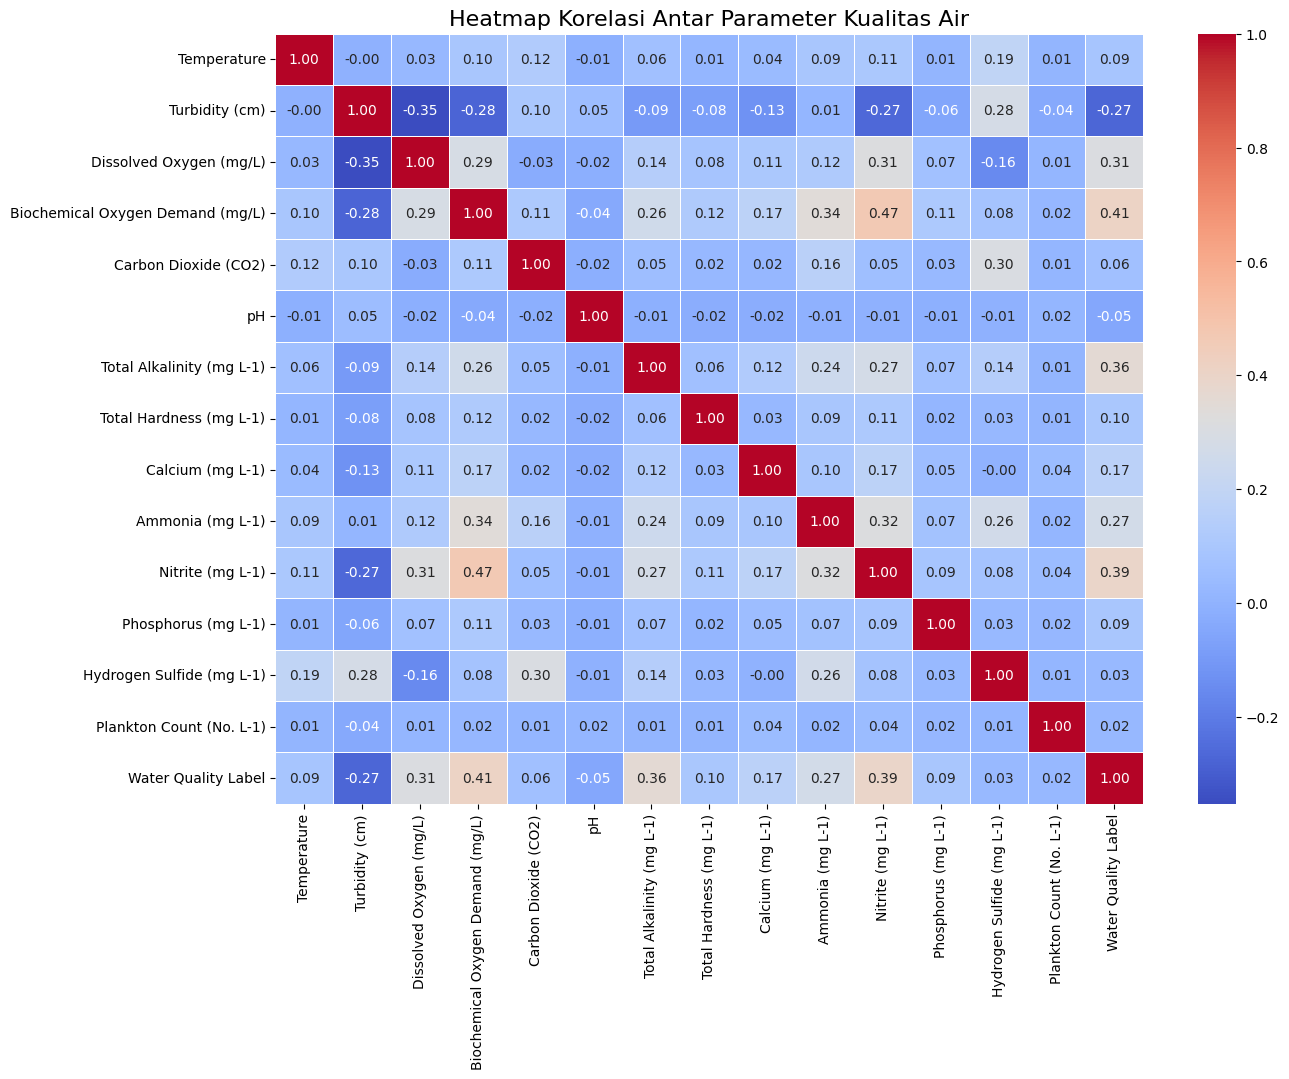

In [6]:
# Korelasi antar fitur numerik
plt.figure(figsize=(14, 10))
numeric_df = dataset.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Parameter Kualitas Air', fontsize=16)
plt.show()


## 3. Data Preprocessing (20%)
Menghapus kolom deskripsi teks yang tidak digunakan, melakukan pembagian data Train/Test, dan menggunakan `RobustScaler` untuk menangani *outliers* yang terlihat pada EDA.

In [7]:
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# 3.1 Drop Label Redundan
cols_to_drop = ['Water Quality Label', 'Aquaculture Suitability Description']
df_clean = dataset.drop(columns=cols_to_drop)

# 3.2 Pemisahan Fitur (X) dan Target Asli (y)
X = df_clean.drop(columns=['Aquaculture Suitability Tier'])
y = df_clean['Aquaculture Suitability Tier']

print("Distribusi Label Asli:")
print(y.value_counts())


Distribusi Label Asli:
Aquaculture Suitability Tier
Reduced Suitability     1500
Moderate Suitability    1400
Optimal Suitability     1400
Name: count, dtype: int64


In [8]:
# 3.3 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')


Train size: (3440, 14), Test size: (860, 14)


## 4. Baseline Model
Bagian ini menggunakan **MLflow** untuk melacak berbagai eksperimen *hyperparameter tuning* pada model Klasifikasi untuk memprediksi *Aquaculture Suitability Tier*.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import RandomizedSearchCV, learning_curve, train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, recall_score, confusion_matrix, classification_report
from lightgbm import LGBMClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# 1. Setup Tracking Server & Experiment Name
mlflow.set_tracking_uri('http://127.0.0.1:5000')
mlflow.set_experiment('aq-water-quality-classification')

In [ ]:
# 2. Data Preparation
# Sesuaikan path ini dengan lokasi dataset Refined_Aquaculture_Water_Suitability_Signals.csv Anda
DATA_PATH = os.getenv("DATA_PATH", "../data/Refined_Aquaculture_Water_Suitability_Signals.csv")
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset tidak ditemukan di path: {DATA_PATH}")

dataset = pd.read_csv(DATA_PATH)
cols_to_drop = ['Aquaculture Suitability Tier', 'Aquaculture Suitability Description']
df_clean = dataset.drop(columns=cols_to_drop)
X = df_clean.drop(columns=['Water Quality Label'])
y = df_clean['Water Quality Label']

# Train-Test Split dengan Stratify karena distribusi label seimbang
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Target folder untuk Baked Model di runtime app
ARTIFACT_DIR = "../app/domains/water/artifacts/water_quality_pipeline"


In [ ]:
# 3. Fungsi Utility: Learning Curve
def plot_learning_curve(pipeline, X_train_data, y_train_data, model_name):
    train_sizes, train_scores, test_scores = learning_curve(
        pipeline, X_train_data, y_train_data, cv=5, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy'
    )
    plt.figure(figsize=(6, 4))
    plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Training score")
    plt.plot(train_sizes, np.mean(test_scores, axis=1), label="Cross-validation score")
    plt.title(f"Learning Curve: {model_name}")
    plt.legend(loc="best")
    plt.grid(True)

In [ ]:
# 4. Baseline Comparison (Fase 1)
baseline_models = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "LogisticRegression": LogisticRegression(random_state=42, max_iter=1000)
}

best_model_name = None
best_roc = 0  # Menggunakan ROC-AUC sebagai acuan seleksi model terbaik

print("--- Memulai Baseline Comparison ---")
with mlflow.start_run(run_name="Baseline_Comparison_Phase"):
    for name, model in baseline_models.items():
        with mlflow.start_run(run_name=name, nested=True):
            # Pipeline: Scaler terikat langsung dengan model classifier
            pipeline = Pipeline([('scaler', RobustScaler()), ('classifier', model)])
            pipeline.fit(X_train, y_train)
            
            # Prediksi untuk evaluasi
            y_pred = pipeline.predict(X_test)
            y_prob = pipeline.predict_proba(X_test) 
            
            # Perhitungan Metrik Secara Komprehensif
            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average='weighted')
            roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovo', average='weighted')
            recall_critical = recall_score(y_test, y_pred, labels=[0], average=None)[0]
            
            # Log parameter dan metrik scalar ke MLflow Tracking Server
            mlflow.log_param("model", name)
            mlflow.log_metrics({
                "accuracy": acc, 
                "f1_weighted": f1, 
                "roc_auc": roc_auc, 
                "recall_critical": recall_critical
            })
            
            print(f"{name} | ROC: {roc_auc:.4f} | Acc: {acc:.4f} | Recall(Crit): {recall_critical:.4f}")

            # Visualisasi & Log Learning Curve ke MLflow Artifact Store
            plot_learning_curve(pipeline, X_train, y_train, name)
            fig = plt.gcf()
            mlflow.log_figure(fig, f"learning_curve_{name}.png")
            plt.close(fig)

            # Logika penentuan model terbaik berbasis ROC-AUC
            if roc_auc > best_roc:
                best_roc = roc_auc
                best_model_name = name

print(f"\nModel terpilih untuk Tuning berdasarkan ROC-AUC: {best_model_name}")


In [ ]:
# 5. Hyperparameter Tuning & Evaluasi Final (Fase 2)
print(f"\n--- Memulai Tahap Tuning Khusus untuk: {best_model_name} ---")

# Ruang parameter yang diketatkan untuk mengendalikan Leaf-wise Overfitting bawaan LightGBM
param_distributions = {
    'classifier__n_estimators': [100, 150, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__max_depth': [3, 5, 7, -1],
    'classifier__num_leaves': [15, 31, 63],          
    'classifier__min_child_samples': [20, 30, 50],   
    'classifier__subsample': [0.7, 0.8, 1.0],         
    'classifier__colsample_bytree': [0.7, 0.8, 1.0]   
}

# Rekonstruksi Pipeline menggunakan model pemenang baseline
tuning_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('classifier', baseline_models[best_model_name])
])

with mlflow.start_run(run_name=f"Tuning_Phase_{best_model_name}"):
    # Optimasi berbasis tertimbang ROC-AUC Multiclass (OVR) via 5-Fold CV
    search = RandomizedSearchCV(
        estimator=tuning_pipeline,
        param_distributions=param_distributions,
        n_iter=20,
        cv=5,
        scoring='roc_auc_ovr_weighted', 
        n_jobs=-1,
        random_state=42
    )
    
    search.fit(X_train, y_train)
    best_pipeline = search.best_estimator_
    
    # Inferensi data uji menggunakan pipeline terbaik hasil tuning
    y_pred_tuned = best_pipeline.predict(X_test)
    y_prob_tuned = best_pipeline.predict_proba(X_test)
    
    # Perhitungan evaluasi final
    final_acc = accuracy_score(y_test, y_pred_tuned)
    final_f1 = f1_score(y_test, y_pred_tuned, average='weighted')
    final_roc_auc = roc_auc_score(y_test, y_prob_tuned, multi_class='ovo', average='weighted')
    final_recall_critical = recall_score(y_test, y_pred_tuned, labels=[0], average=None)[0]
    
    # Registrasi parameters dan metrics ke server
    mlflow.log_params(search.best_params_)
    mlflow.log_metrics({
        "final_accuracy": final_acc,
        "final_f1_weighted": final_f1,
        "final_roc_auc": final_roc_auc,
        "final_recall_critical": final_recall_critical
    })
    
    print("\n=== Hasil Tuning Optimal ===")
    print(f"Best Params: {search.best_params_}")
    print(f"ROC-AUC Final: {final_roc_auc:.4f} | Accuracy Final: {final_acc:.4f} | Recall(Crit) Final: {final_recall_critical:.4f}")
    
    # Artifact 1: Final Learning Curve
    print("\nGenerating Final Learning Curve...")
    plot_learning_curve(best_pipeline, X_train, y_train, f"Tuned_{best_model_name}")
    fig_lc = plt.gcf()
    mlflow.log_figure(fig_lc, f"artifacts/learning_curve_tuned_{best_model_name}.png")
    plt.close(fig_lc)
    
    # Artifact 2: Confusion Matrix Heatmap
    cm = confusion_matrix(y_test, y_pred_tuned)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
    plt.title(f'Confusion Matrix: Tuned {best_model_name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    fig_cm = plt.gcf()
    mlflow.log_figure(fig_cm, "artifacts/confusion_matrix.png")
    plt.close(fig_cm)
    
    # Artifact 3: Classification Report Text File (.txt) sebagai audit trail
    report = classification_report(y_test, y_pred_tuned)
    report_path = "classification_report.txt"
    with open(report_path, "w") as f:
        f.write(report)
    mlflow.log_artifact(report_path, "artifacts")
    
    print("\n--- Final Classification Report ---")
    print(report)
    
    # 6. REGISTRASI MODEL (Model Registry)
    # Pipeline utuh dikunci ke Model Registry server untuk kesiapan penarikan stage oleh app/
    mlflow.sklearn.log_model(
        sk_model=best_pipeline,
        artifact_path="water_quality_pipeline",
        registered_model_name="EWS_LightGBM_Production"
    )

print("\n[SUKSES] Seluruh alur MLOps dari Baseline hingga Tuning selesai terekam di MLflow.")